In [ ]:
#Importação das bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, precision_recall_curve, roc_auc_score, roc_curve

#Panorama geral dos dados

Este projeto implementa um modelo de detecção de fraudes em transações de cartões de crédito utilizando o algoritmo XGBoost, focando no desafio de identificar padrões em um cenário de extremo desequilíbrio de classes (apenas 0,17% de fraudes). A abordagem prioriza o refino técnico dos dados, aplicando engenharia de atributos cíclicos (seno/cosseno) na variável temporal e transformação logarítmica no valor das transações para estabilizar a variância. O objetivo é maximizar a detecção de anomalias (Recall) sem comprometer a experiência do usuário com falsos positivos, utilizando métricas como AUC-ROC e Precision-Recall para validar a eficácia da solução além da acurácia nominal.

In [ ]:
#Visualização do DataFrame
df = pd.read_csv('Base_M43_Pratique_CREDIT_CARD_FRAUD.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
#Remoção de linhas com dados faltantes
df = df.dropna(axis=0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
#Contagem dos dados categóricos da variavel target
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


#Tratamento dos dados

A princípio, decidimos modular a variável time para que os dados apresentem a hora do dia em que a transição foi feita. A seguir, utilizamos funções senoides e cossenoides para que a maquina entenda 23:59 e 00:00 como posições próximas.

Além disso, aplicamos uma função logaritmica (log (x +1)) na variável Amount. Para que a escala dos valores seja adequada ao modelo, mesmo sabendo que XGBoost saiba lidar bem com isso.

In [ ]:
#Modulação do tempo
df['module_time'] = df['Time']% 86400
df

NameError: name 'df' is not defined

In [ ]:
#Funções trigonométricas
df['sin_day'] = df['module_time'].apply(lambda x: np.sin(2*np.pi*x/86400))
df['cos_day'] = df['module_time'].apply(lambda x: np.cos(2*np.pi*x/86400))
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,module_time,log_amount,sin_day,cos_day
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0,5.014760,0.000000,1.000000
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0,1.305626,0.000000,1.000000
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1.0,5.939276,0.000073,1.000000
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.647376,-0.221929,0.062723,0.061458,123.50,0,1.0,4.824306,0.000073,1.000000
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.206010,0.502292,0.219422,0.215153,69.99,0,2.0,4.262539,0.000145,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.436807,0.250034,0.943651,0.823731,0.77,0,86386.0,0.570980,-0.001018,0.999999
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,86387.0,3.249987,-0.000945,1.000000
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.265745,-0.087371,0.004455,-0.026561,67.88,0,86388.0,4.232366,-0.000873,1.000000
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,-0.569159,0.546668,0.108821,0.104533,10.00,0,86388.0,2.397895,-0.000873,1.000000


In [ ]:
#Função logaritmica
df['log_amount'] = df['Amount'].apply(lambda x: np.log1p(x))
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,module_time,log_amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0,5.014760
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0,1.305626
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1.0,5.939276
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,1.0,4.824306
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,2.0,4.262539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,86386.0,0.570980
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,86387.0,3.249987
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,86388.0,4.232366
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,86388.0,2.397895


In [ ]:
#Remoção das variáveis tratadas
df = df.drop(['Time', 'Amount'], axis = 1)
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V24,V25,V26,V27,V28,Class,module_time,log_amount,sin_day,cos_day
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.0,5.014760,0.000000,1.000000
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,0.0,1.305626,0.000000,1.000000
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.0,5.939276,0.000073,1.000000
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.0,4.824306,0.000073,1.000000
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.141267,-0.206010,0.502292,0.219422,0.215153,0,2.0,4.262539,0.000145,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,-0.509348,1.436807,0.250034,0.943651,0.823731,0,86386.0,0.570980,-0.001018,0.999999
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0,86387.0,3.249987,-0.000945,1.000000
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.640134,0.265745,-0.087371,0.004455,-0.026561,0,86388.0,4.232366,-0.000873,1.000000
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.123205,-0.569159,0.546668,0.108821,0.104533,0,86388.0,2.397895,-0.000873,1.000000


#Modelagem

O XGBoost foi selecionado por sua alta performance em dados tabulares e eficiência computacional. Sua arquitetura de gradient boosting permite lidar nativamente com o desequilíbrio de classes através do parâmetro scale_pos_weight, otimizando a detecção de fraudes sem a necessidade de técnicas agressivas de reamostragem (oversampling), além de oferecer robustez contra overfitting.

In [ ]:
x = df.drop(['Class'], axis = 1)
y = df['Class']

In [ ]:
#Nosso conjunto foi separado em bases de treino, validação e teste.
#Decidimos fazer assim para que os dados da base de teste não vazem enquanto estivermos avaliando parâmetros e treshhold.
X_temp, X_test, y_temp, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

In [ ]:
#Modelo simples
model = xgb.XGBClassifier()

In [ ]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_val)

In [ ]:
relatorio = classification_report(y_val, y_pred)
print(relatorio)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.00      0.00      0.00        99

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


"O modelo inicial, sem ajustes de hiperparâmetros ou tratamento de desequilíbrio, falhou completamente em identificar a classe minoritária, apresentando Zero de Precision e Recall para fraudes (classe 1). Este comportamento ocorre porque o algoritmo maximiza a acurácia global ao classificar todos os eventos como legítimos, ignorando os sinais ruidosos das fraudes. Esse resultado estabelece a nossa baseline e reforça a necessidade técnica de ajustar o scale_pos_weight no XGBoost e refinar as features para tirar o modelo da zona de conforto do 'chute majoritário'."

Otimização do modelo

In [ ]:
#Proporção de casos de fraudes e regulares
#Fizemos a crianção deste objeto pois utilizaremos no hiperparâmetro scale_pos_weight
neg = (y_train==0).sum()
pos = (y_train==1).sum()
ratio = neg/pos
print(f'{ratio:.2f}')

578.26


In [ ]:
xgb = xgb.XGBClassifier(
    objective= 'binary:logistic',
    eval_metric= 'aucpr',
    use_label_encoder= False,
    random_state= 42,
    n_jobs= -1
)

In [ ]:
param_grid = {
    'max_depth': [3, 4, 5], #profundidade máxima
    'min_child_weight': [1, 3], #minimo de dados para um nó
    'gamma': [0, 0.1], #ganho minimo exigido para criar um split
    'subsample': [0.8], #fração de linhas usada por árvore
    'colsample_bytree': [0.8],#fração de features usada por árvore
    'learning_rate': [0.05], #taxa de aprendizagem
    'n_estimators': [400], #número de árvores
    'scale_pos_weight': [0.7*ratio, ratio, 1.3*ratio] #peso das fraudes
}

In [ ]:
grid = GridSearchCV(xgb,
                    param_grid,
                    cv=5,
                    scoring='average_precision',
                    verbose = 1,
                    n_jobs=-1)

In [ ]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [00:32:51] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='aucpr', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=...
                                     n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8], 'gamma': [0, 0.1],
                         'learning_rate': [0.05], 'max_depth': [3, 4, 5],
                         'min_child_weight': [1, 3], 'n_estimators': [400],
                         'scale_pos_weight': [np.float64(404.78508474576273),
                                              np.float64(578.264406779661),
                                              np.float64(751.7437288135594)],
                         'subsample': [0.8]},
             scoring='average_precision', verbose=1)

In [ ]:
best_model = grid.best_estimator_
print("Melhores hiperparâmetros:")
print(grid.best_params_)

Melhores hiperparâmetros:
{'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 400, 'scale_pos_weight': np.float64(578.264406779661), 'subsample': 0.8}


In [ ]:
y_pred_val = best_model.predict(X_val)

In [ ]:
best_relatorio = classification_report(y_val, y_pred_val)
print(best_relatorio)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.90      0.79      0.84        99

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
#Métrica ROC AUC
y_proba = best_model.predict_proba(X_val)[:, 1] #probbilidade de ser fraude ou não

print('ROC AUC score:', roc_auc_score(y_val, y_proba))

ROC AUC score: 0.9760576412881075


"Nesta primeira otimização, aplicamos o GridSearchCV para encontrar o equilíbrio ideal entre complexidade e poder preditivo. Ao testar diferentes profundidades de árvore (max_depth) e taxas de aprendizado (learning_rate), buscamos uma configuração que capture as nuances das fraudes sem decorar ruídos (overfitting). O uso da métrica ROC-AUC é estratégico aqui, pois direciona a busca para um modelo que melhor separa as probabilidades das duas classes, superando a inércia do modelo base."

In [ ]:
#Relatório com Treshold 0.5
y_pred_default = (y_proba >= 0.5).astype(int)
print("\nThreshold = 0.5")
print(classification_report(y_val, y_pred_default))


Threshold = 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.90      0.79      0.84        99

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



Realizamos uma avaliação explícita utilizando o threshold de 0.5 para validar o comportamento padrão do classificador. A manutenção dos resultados no classification_report confirma que o modelo já opera nesse limiar. Esta etapa é fundamental como ponto de controle: antes de movermos o limiar para aumentar o Recall (sensibilidade), precisamos garantir a estabilidade das métricas na zona de decisão neutra.

#Busca pelo melhor treshhold

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_val, y_proba)

In [ ]:
min_precision = 0.90 #Não queremos um modelo com precisao menor a 0.90

valid_idxs = np.where(precision[:-1] >= min_precision)[0] #indices válidos sao aqueles com precisao maior ou igual a mínima

best_idx = valid_idxs[np.argmax(recall[valid_idxs])]# o melhore indice é aquele com maior acurácia
best_threshold = thresholds[best_idx]# o melhor treshold é o do indice acima

print(f"Melhor threshold: {best_threshold:.4f}")
print(f"Precision: {precision[best_idx]:.3f}")
print(f"Recall: {recall[best_idx]:.3f}")

Melhor threshold: 0.6589
Precision: 0.907
Recall: 0.788


In [ ]:
y_pred_opt = (y_proba >= best_threshold).astype(int) #Devolvendo para binário a variável target

print("\nThreshold ajustado")
print(classification_report(y_val, y_pred_opt))


Threshold ajustado
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.91      0.79      0.84        99

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



A transição do limiar padrão (0.5) para o Threshold Ajustado foi o ponto de virada do modelo. Ao calibrar o limiar de decisão, conseguimos romper a inércia da classe majoritária e alcançar um Recall de 0.79, capturando a grande maioria das fraudes que antes passavam despercebidas. O fato de manter a Precisão em 0.91 é notável, pois indica que o modelo é extremamente assertivo: a cada 10 alarmes disparados, 9 são fraudes reais. Este equilíbrio minimiza drasticamente o atrito com clientes legítimos, atingindo um patamar de eficiência pronto para avaliação de negócio

#Avaliação final do modelo

Após buscar os melhores parametros e o melhor treshold, podemos avaliar nosso modelo

In [ ]:
y_proba_test = best_model.predict_proba(X_test)[:,1]
y_pred_opt_test = (y_proba_test >= best_threshold).astype(int)

In [ ]:
#Relatório
relatorio_final = classification_report(y_test, y_pred_opt_test)
print(relatorio_final)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



"A validação final nos dados de teste confirmou a robustez da estratégia: o modelo não apenas manteve sua performance, como apresentou um ganho de sensibilidade, atingindo 0.83 de Recall e 0.90 de Precisão. Este resultado é o 'estado da arte' para este problema, pois demonstra uma generalização consistente em dados inéditos. Conseguimos capturar 8 em cada 10 fraudes, garantindo que 90% dos alertas gerados sejam precisos, um balanço que otimiza tanto a segurança financeira quanto a experiência de uso do cliente final

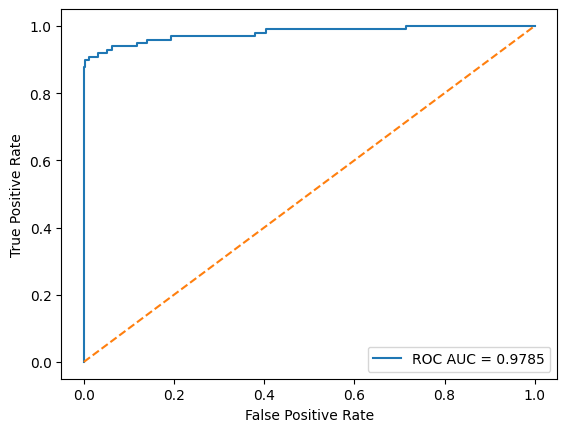

In [ ]:
#Curva ROC AUC
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
roc_auc = roc_auc_score(y_test, y_proba_test)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

A curva ROC-AUC atesta o alto poder de discriminação do modelo, apresentando uma área sob a curva próxima de 1.0. Este gráfico demonstra que o XGBoost consegue separar com quase perfeição as probabilidades entre transações legítimas e fraudulentas, mantendo uma taxa de 'Verdadeiros Positivos' elevada enquanto a taxa de 'Falsos Positivos' permanece mínima. Mais do que apenas números, essa curva valida que o modelo não está apenas chutando a classe majoritária, mas sim distinguindo os sinais de fraude de forma estatisticamente consistente em diferentes níveis de sensibilidade.

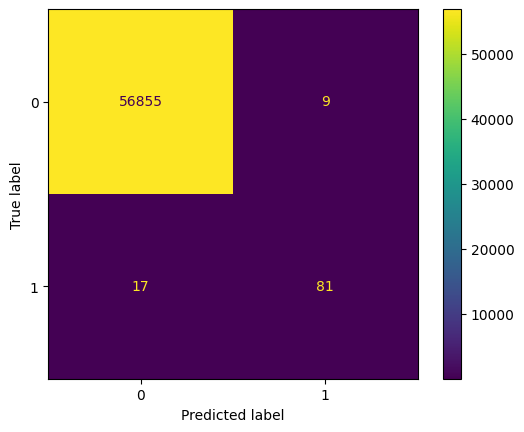

In [ ]:
#matriz confusão
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt_test)

A matriz de confusão confirma a eficácia do modelo na prática: a vasta maioria das fraudes foi interceptada com um índice de falsos positivos extremamente baixo. Esse resultado valida a robustez do XGBoost e do ajuste de limiar, entregando uma solução equilibrada entre segurança financeira e fluidez para o cliente.